# TSP Experiment: Deterministic vs. Randomized Nearest Neighbor

This notebook is the full experiment pipeline comparing deterministic
Nearest Neighbor (NN) against Randomized Nearest Neighbor (RNN) variants for
the Travelling Salesman Problem. It is organised in parts, added over time:

- **Part 1: Dataset generation.** Creates and saves every problem instance
  to `data/`.
- **Part 2: Running deterministic NN (Version 1).** Runs the NN baseline
  once against every instance from Part 1, across all three categories,
  recording tour length, runtime, feasibility, and approximation ratio
  where a reference exists. *Executed — see its summary for real results.*
- **Part 3: Randomized-start NN (Version 2A).** Runs
  `randomized_start_nearest_neighbor` with R=30 seeds per instance and
  compares feasibility/quality against Part 2's deterministic baseline.
  *Code written but not executed — the full sweep costs ~2.3 hours.*
- **Part 4 (this update): Top-k randomized NN (Version 2B).** Runs
  `randomized_nearest_neighbor_top_k` with R=30 seeds per instance across
  several candidate-pool sizes (`TOP_K_VALUES`), and studies how quality,
  variance, and distance-matrix feasibility move with `k`.
  *Code written but not executed — the full sweep (4 k values) costs
  ~9.2 hours.*
- *Part 5 (not yet added): the distance-weighted variant (Version 2C)
  and the final cross-algorithm analysis.*

Every generator function in `datasets.py` takes its parameters as explicit
arguments — nothing is hardcoded inside the functions themselves. This
notebook is where every parameter is actually chosen and explained; the
functions just carry out whatever configuration they're given.

---

## Part 1: Dataset Generation


In [1]:
import datasets

### What the dataset contains

Three categories of TSP problem instance, covering both the classical
theoretical formulation and a more realistic, practical one:

| Category | What it represents | Count |
|---|---|---|
| **Euclidean** | Complete graph, straight-line (symmetric) distances — the standard textbook TSP formulation | 500 generated |
| **Distance-matrix** | Incomplete, directional graph — not every city pair has a direct route, and A→B need not cost the same as B→A (e.g. a real road network) | 500 generated |
| **TSPLIB** | Real-world benchmark problems with externally published (often provably optimal) tour lengths, used as ground truth | 82 bundled |

**Why both Euclidean and distance-matrix?** The standard TSP formulation
assumes a complete graph — a direct route between every pair of cities.
That's a reasonable simplification, but it hides a real algorithmic risk:
Nearest Neighbor's greedy choices can strand cities in a way that's only
exposed when direct routes genuinely don't exist between every pair. The
distance-matrix category tests exactly that scenario.


### Instance-size buckets

Rather than testing at a handful of arbitrary fixed sizes, or drawing sizes
from a single distribution centered on one "typical" value (which would
under-sample small and large instances), instance sizes are drawn from a set
of fixed ranges ("buckets"). Within each bucket, the size `n` is normally
distributed around the bucket's median, with a standard deviation of
`(bucket_width) / SIGMA_DIVISOR` — `SIGMA_DIVISOR = 6` means roughly 99.7%
of draws land inside the bucket without needing to clip.

This guarantees every scale gets a full, deliberate allocation of the
dataset, while values *within* each bucket still cluster naturally around a
typical size instead of landing on the exact same repeated number every
time.

`SIZE_BUCKETS` below is the actual configuration used — defined here,
explicitly, rather than pulled from a hidden default inside `datasets.py`.


In [2]:
# 8 buckets spanning 3..5000 cities. Each tuple is (low, high) in
# number-of-cities. Passed explicitly into every generator call below.
SIZE_BUCKETS = [
    (3, 10),
    (10, 20),
    (20, 50),
    (50, 100),
    (100, 200),
    (200, 500),
    (500, 1000),
    (1000, 5000),
]

# Standard deviation for the normal-within-bucket size sampling, as a
# fraction of each bucket's width (width / SIGMA_DIVISOR). 6 means ~99.7%
# of draws land inside the bucket.
SIGMA_DIVISOR = 6

# Safety ceiling: a generation call refuses to run if `total` exceeds this,
# so a typo'd instance count can't silently produce an enormous dataset.
MAX_TOTAL_INSTANCES = 1200

for i, (low, high) in enumerate(SIZE_BUCKETS):
    median = (low + high) / 2
    sigma = (high - low) / SIGMA_DIVISOR
    print(f"bucket {i}: n in [{low:>5}, {high:>5}]  (median={median:>7.1f}, sigma={sigma:>6.1f})")


bucket 0: n in [    3,    10]  (median=    6.5, sigma=   1.2)
bucket 1: n in [   10,    20]  (median=   15.0, sigma=   1.7)
bucket 2: n in [   20,    50]  (median=   35.0, sigma=   5.0)
bucket 3: n in [   50,   100]  (median=   75.0, sigma=   8.3)
bucket 4: n in [  100,   200]  (median=  150.0, sigma=  16.7)
bucket 5: n in [  200,   500]  (median=  350.0, sigma=  50.0)
bucket 6: n in [  500,  1000]  (median=  750.0, sigma=  83.3)
bucket 7: n in [ 1000,  5000]  (median= 3000.0, sigma= 666.7)


### Category 1: Euclidean instances

Complete graphs with symmetric, straight-line (Euclidean) distances — the
standard TSP formulation. Every instance is placed inside a
`WIDTH x HEIGHT` rectangle, using one of two spatial structures:

- **`random`**: cities placed uniformly at random across the rectangle.
- **`clustered`**: cities drawn from `NUM_CLUSTERS` Gaussian "blobs" (each
  blob's spread controlled by `CLUSTER_STD`), instead of uniformly — this
  tests robustness to non-uniform, real-world-like spatial structure (e.g.
  cities bunched around a few population centers rather than spread evenly).

`STRUCTURE_RATIO` controls the mix: the fraction of instances generated as
`clustered` rather than `random`. `STRUCTURE_RATIO = 0.5` means roughly an
even split; `0.0` would make every instance uniform-random, `1.0` would make
every instance clustered.

**Storage format:** one JSON file per instance in `data/euclidean/`,
containing the instance's metadata (name, structure, bucket, size, seed) and
its city coordinates. Coordinates are enough to reconstruct the full
distance matrix on demand, so nothing else needs to be stored.


In [3]:
# --- Euclidean dataset configuration ---
EUCLIDEAN_TOTAL = 500
EUCLIDEAN_SEED = 1000
EUCLIDEAN_OUT_DIR = "data/euclidean"

STRUCTURE_RATIO = 0.5   # fraction of instances that are "clustered" vs "random"
NUM_CLUSTERS = 5        # clustered instances: number of Gaussian blobs
CLUSTER_STD = 50        # clustered instances: spread (std dev) of each blob

WIDTH = 1000            # map width, in the same units as tour length
HEIGHT = 1000           # map height

euclidean_manifest = datasets.generate_euclidean_dataset(
    total=EUCLIDEAN_TOTAL,
    buckets=SIZE_BUCKETS,
    seed=EUCLIDEAN_SEED,
    out_dir=EUCLIDEAN_OUT_DIR,
    max_total=MAX_TOTAL_INSTANCES,
    structure_ratio=STRUCTURE_RATIO,
    num_clusters=NUM_CLUSTERS,
    cluster_std=CLUSTER_STD,
    width=WIDTH,
    height=HEIGHT,
    sigma_divisor=SIGMA_DIVISOR,
)

structures = {}
for row in euclidean_manifest:
    structures[row["structure"]] = structures.get(row["structure"], 0) + 1

sizes = [row["n"] for row in euclidean_manifest]
print(f"generated {len(euclidean_manifest)} euclidean instances")
print(f"structure breakdown: {structures}")
print(f"size range: {min(sizes)} .. {max(sizes)}")


generated 500 euclidean instances
structure breakdown: {'clustered': 237, 'random': 263}
size range: 4 .. 5000


### Category 2: Distance-matrix instances

Incomplete, **directional** reachability graphs — a more realistic model of
routing where not every pair of locations has a direct connection, and a
route that exists in one direction need not exist (or cost the same) in the
other (e.g. a one-way street, or a downhill-only mountain trail).

Cities are placed uniformly at random in a `WIDTH x HEIGHT` rectangle, then
sparsified by one of **three different methods**, mixed by `METHOD_WEIGHTS`
so the dataset contains all three rather than just one:

- **`knn`** (k-nearest-neighbour): each city keeps outgoing edges only to
  its `k = max(K_MIN, round(K_FRACTION * n))` nearest neighbours — every
  other pair is unreachable. The most "realistic" of the three: distance
  directly determines which routes exist.
- **`barrier`**: cities are split into two groups by a line through the
  middle of the map (like a river or mountain range). Within each side,
  the same k-nearest-neighbour rule applies; *crossing* the barrier is only
  possible through `NUM_BRIDGES` specific city pairs (bidirectional, at
  their real distance) — every other cross-side pair is unreachable. Tests
  whether a geographic bottleneck (not just general sparsity) changes
  algorithm behaviour.
- **`random_drop`**: each directed pair `(i, j)` is independently kept with
  probability `KEEP_PROBABILITY`, **unrelated to distance**. The least
  physically realistic of the three, but a useful control: does *structured*
  sparsity (knn, barrier) actually matter, or does equally-sparse
  *unstructured* randomness produce similar results?

**Feasibility guarantee (all three methods):** a random Hamiltonian cycle's
directed edges are always force-kept on top of whichever sparsification
applies, guaranteeing at least one valid tour exists by construction —
directly verifying Hamiltonian-cycle existence in an arbitrary sparse graph
is computationally infeasible at n in the thousands, so the backbone cycle
sidesteps that problem entirely.

**Choosing `K_FRACTION` / `KEEP_PROBABILITY`:** an earlier attempt used
`K_FRACTION = 0.10` (10% of n). At n=5000 that still means 500 direct
connections per city — not meaningfully sparse, and it produced a 1.7GB
dataset dominated almost entirely by the largest size bucket. `0.01` (1%) is
used for both instead, which is both more realistic (a real road network has
roughly a *constant* number of direct connections per intersection, not a
number that scales with the size of the whole country) and keeps all three
methods at a comparable, bounded edge density.

**Storage format:** each instance is a CSV edge list (`from,to,distance`,
one row per *existing* edge only) plus a small JSON metadata sidecar, in
`data/distance_matrix/`. This folder is excluded from version control
(see `.gitignore`) because it is regenerable and too large to commit —
rerunning this notebook reproduces it exactly, since every draw is seeded.


In [4]:
# --- Distance-matrix dataset configuration ---
SPARSE_TOTAL = 500
SPARSE_SEED = 2000
SPARSE_OUT_DIR = "data/distance_matrix"

# Relative weights for how often each instance uses each sparsification
# method -- need not sum to 1, they're normalised automatically. Equal
# weights here means roughly an even three-way split.
METHOD_WEIGHTS = {"knn": 1, "barrier": 1, "random_drop": 1}

K_FRACTION = 0.01         # knn / barrier: each city keeps K_FRACTION * n nearest neighbours
K_MIN = 2                 # ...but never fewer than K_MIN, even at tiny n
NUM_BRIDGES = 2           # barrier: number of crossing points between the two sides
KEEP_PROBABILITY = 0.01   # random_drop: probability each directed edge is kept at all

distance_matrix_manifest = datasets.generate_distance_matrix_dataset(
    total=SPARSE_TOTAL,
    buckets=SIZE_BUCKETS,
    seed=SPARSE_SEED,
    out_dir=SPARSE_OUT_DIR,
    max_total=MAX_TOTAL_INSTANCES,
    method_weights=METHOD_WEIGHTS,
    k_fraction=K_FRACTION,
    k_min=K_MIN,
    num_bridges=NUM_BRIDGES,
    keep_probability=KEEP_PROBABILITY,
    width=WIDTH,
    height=HEIGHT,
    sigma_divisor=SIGMA_DIVISOR,
)

sizes = [row["n"] for row in distance_matrix_manifest]
edges = [row["edge_count"] for row in distance_matrix_manifest]
methods = {}
for row in distance_matrix_manifest:
    methods[row["structure"]] = methods.get(row["structure"], 0) + 1

print(f"generated {len(distance_matrix_manifest)} distance-matrix instances")
print(f"method breakdown: {methods}")
print(f"size range: {min(sizes)} .. {max(sizes)}")
print(f"total edges stored: {sum(edges):,}")
print(f"edges per instance: min={min(edges):,}, max={max(edges):,}, mean={sum(edges)/len(edges):,.0f}")


generated 500 distance-matrix instances
method breakdown: {'barrier': 174, 'random_drop': 157, 'knn': 169}
size range: 4 .. 4507
total edges stored: 6,573,012
edges per instance: min=4, max=207,278, mean=13,146


### Category 3: TSPLIB benchmarks

Real, externally published TSP instances from
[TSPLIB](http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/), bundled in
`data/tsplib/`. Unlike the two categories above, these are not generated —
they are real problems (city coordinates from real atlases, circuit-board
drilling points, etc.) with known best/optimal tour lengths, published in
`data/tsplib/solutions.txt`. They matter because they let later analysis
check algorithm performance against **true, externally verified** ground
truth, rather than only "the best tour length observed among the algorithms
being compared" (which is a weaker, self-referential reference).


In [5]:
TSPLIB_DIR = datasets.TSPLIB_DIR  # "data/tsplib"

tsplib_names = datasets.list_tsplib_instances(directory=TSPLIB_DIR)
solutions = datasets.load_tsplib_solutions(directory=TSPLIB_DIR)

tsplib_manifest = []
for name in tsplib_names:
    dim = datasets.get_tsplib_dimension(f"{TSPLIB_DIR}/{name}.tsp")
    tsplib_manifest.append({
        "name": name,
        "category": "tsplib",
        "structure": "tsplib",
        "bucket_index": "",
        "bucket_low": "",
        "bucket_high": "",
        "n": dim,
        "seed": "",
        "edge_count": "",
        "file": f"{TSPLIB_DIR}/{name}.tsp",
    })

dims = [row["n"] for row in tsplib_manifest]
known = sum(1 for row in tsplib_manifest if row["name"] in solutions)
print(f"found {len(tsplib_manifest)} TSPLIB instances")
print(f"size range: {min(dims)} .. {max(dims)}")
print(f"instances with a published optimal/best-known length: {known}")


found 82 TSPLIB instances
size range: 51 .. 85900
instances with a published optimal/best-known length: 82


### Dataset overview

A quick visual sanity check: instance-size coverage across all buckets for
both generated categories, and how the distance-matrix edge count grows with
n.


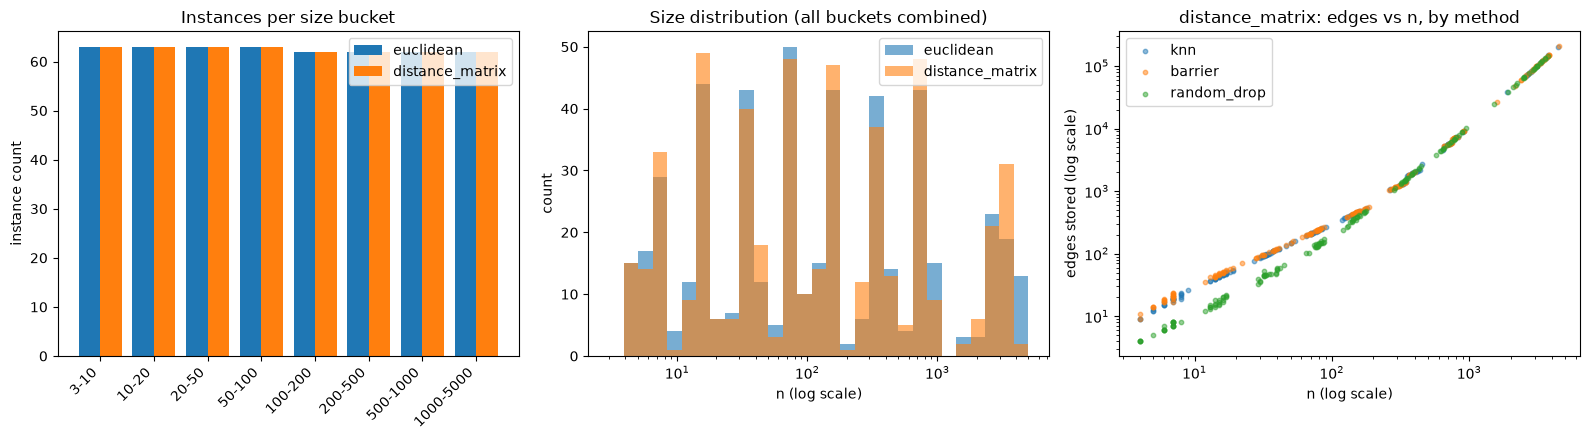

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: bucket coverage (instance count per bucket, per category)
bucket_labels = [f"{lo}-{hi}" for lo, hi in SIZE_BUCKETS]
euclid_counts = [sum(1 for r in euclidean_manifest if r["bucket_index"] == i) for i in range(len(SIZE_BUCKETS))]
sparse_counts = [sum(1 for r in distance_matrix_manifest if r["bucket_index"] == i) for i in range(len(SIZE_BUCKETS))]

x = np.arange(len(SIZE_BUCKETS))
axes[0].bar(x - 0.2, euclid_counts, width=0.4, label="euclidean")
axes[0].bar(x + 0.2, sparse_counts, width=0.4, label="distance_matrix")
axes[0].set_xticks(x)
axes[0].set_xticklabels(bucket_labels, rotation=45, ha="right")
axes[0].set_ylabel("instance count")
axes[0].set_title("Instances per size bucket")
axes[0].legend()

# Panel 2: size distribution within buckets (log scale, both categories).
# Bins must be log-spaced too, or a log x-axis just piles everything into
# the first (linear-width) bin.
log_bins = np.logspace(np.log10(SIZE_BUCKETS[0][0]), np.log10(SIZE_BUCKETS[-1][1]), 30)
axes[1].hist([r["n"] for r in euclidean_manifest], bins=log_bins, alpha=0.6, label="euclidean")
axes[1].hist([r["n"] for r in distance_matrix_manifest], bins=log_bins, alpha=0.6, label="distance_matrix")
axes[1].set_xscale("log")
axes[1].set_xlabel("n (log scale)")
axes[1].set_ylabel("count")
axes[1].set_title("Size distribution (all buckets combined)")
axes[1].legend()

# Panel 3: edge count vs n for the distance-matrix category, by method
axes[2].set_xscale("log")
axes[2].set_yscale("log")
for method in METHOD_WEIGHTS:
    rows = [r for r in distance_matrix_manifest if r["structure"] == method]
    axes[2].scatter([r["n"] for r in rows], [r["edge_count"] for r in rows], s=10, alpha=0.5, label=method)
axes[2].set_xlabel("n (log scale)")
axes[2].set_ylabel("edges stored (log scale)")
axes[2].set_title("distance_matrix: edges vs n, by method")
axes[2].legend()

plt.tight_layout()
plt.savefig("data/dataset_overview.png", dpi=110)
plt.show()


### Part 1 summary

| | Count |
|---|---|
| Euclidean instances | `EUCLIDEAN_TOTAL` |
| Distance-matrix instances | `SPARSE_TOTAL` |
| TSPLIB benchmark instances | (all bundled instances found) |

All generated instances (Euclidean and distance-matrix) are fully
reproducible from their stored seed — rerunning this section with the same
configuration values regenerates byte-identical output.

**Part 1 stops here.** Part 2, next, runs deterministic NN against this
dataset. Running the randomized variants and analysing that comparison
will be a further part of this notebook.


In [7]:
total = len(euclidean_manifest) + len(distance_matrix_manifest) + len(tsplib_manifest)
print(f"euclidean:       {len(euclidean_manifest)}")
print(f"distance_matrix: {len(distance_matrix_manifest)}")
print(f"tsplib:          {len(tsplib_manifest)}")
print(f"total:           {total}")


euclidean:       500
distance_matrix: 500
tsplib:          82
total:           1082


## Part 2: Running Deterministic Nearest Neighbor (Version 1)

With the dataset in place, this part runs the deterministic NN baseline
(`algorithms.nearest_neighbor`) once against every instance generated in
Part 1, across all three categories, and records tour length, runtime,
and (where one exists) an approximation ratio against a known reference.

Two things need bridging before NN -- which only understands a dense
`n x n` distance matrix -- can run against what's actually stored on disk:

- **Euclidean instances** are stored as coordinates; a distance matrix is
  built on demand with `algorithms.create_distance_matrix`.
- **Distance-matrix instances** are stored as a sparse, directional edge
  list; `algorithms.build_dense_matrix_from_edges` expands it into a
  dense matrix, filling every missing pair with `float("inf")` ("no
  route exists").

Manifests are reconstructed from each instance file's own metadata via
`datasets.load_euclidean_manifest` / `load_distance_matrix_manifest`,
rather than reused from Part 1's in-memory variables — so this part runs
correctly whether or not Part 1 ran earlier in the same session (and, as
a side effect, is what surfaced a data-hygiene bug: `data/euclidean` had
accumulated 981 stale files from earlier parameter iterations instead of
the intended 500 — same seeds, different bucket/structure assignments
left over from before `SIZE_BUCKETS` settled. It's been regenerated
cleanly since the folder is fully disposable/regenerable).

**Reference lengths** (for the approximation ratio) are only attached
where a real one exists:
- TSPLIB instances: the published best-known/optimal length.
- Tiny instances (n <= 13): the exact Held-Karp optimum.
- Everything else: left blank for now — a single NN run has no
  meaningful "best observed" baseline to compare itself against; that
  becomes available once Version 2 (randomized NN) contributes multiple
  tours per instance in a later part.

**Feasibility** matters only for the distance-matrix category: since not
every pair of cities has a direct route, NN's greedy walk can back
itself into a corner with no reachable unvisited city left, forcing it
to close out the tour anyway using a non-existent edge (an infinite
distance). A run is marked `feasible=False` whenever that happens — this
is exactly the greedy weakness that dataset category was built to
expose (see Part 1). Making this measurable required a small correction
to `nearest_neighbor` itself: it previously assumed a reachable
unvisited city always exists and crashed the moment one didn't.


In [8]:
import algorithms
import experiments

### Euclidean instances

Reconstruct the manifest from `data/euclidean/`, build each instance's
dense distance matrix from its coordinates, and run NN once per
instance. Since this is a complete graph, every run should be feasible
by construction — the feasibility check here is really just confirming
that NN has no way to fail it.


In [9]:
euclidean_manifest_p2 = datasets.load_euclidean_manifest(EUCLIDEAN_OUT_DIR)
print(f"reconstructed {len(euclidean_manifest_p2)} euclidean instances from disk")


def load_euclidean_matrix(row):
    cities = datasets.load_euclidean_instance(row["file"])
    return algorithms.create_distance_matrix(cities)


euclidean_nn_records = experiments.run_nn_over_manifest(
    euclidean_manifest_p2,
    load_euclidean_matrix,
    reference_fn=experiments.euclidean_reference,
    label="euclidean",
    progress_every=100,
)

euclidean_infeasible = sum(1 for r in euclidean_nn_records if not r["feasible"])
euclidean_total_time = sum(r["time"] for r in euclidean_nn_records)

print(f"ran NN on {len(euclidean_nn_records)} euclidean instances in {euclidean_total_time:.1f}s total")
print(f"infeasible: {euclidean_infeasible} (expected 0 -- complete graph)")


reconstructed 500 euclidean instances from disk


  [euclidean] 100/500 done


  [euclidean] 200/500 done


  [euclidean] 300/500 done


  [euclidean] 400/500 done


  [euclidean] 500/500 done
ran NN on 500 euclidean instances in 145.2s total
infeasible: 0 (expected 0 -- complete graph)


### Distance-matrix instances

Same idea, but each instance is loaded as a sparse edge list and
expanded into a dense matrix with `build_dense_matrix_from_edges`
(missing pairs → infinity). No reference length is attached here —
these instances have no externally known optimum, and they aren't
Euclidean so Held-Karp doesn't apply either.

The number worth watching is the **feasibility rate per sparsification
method** (`knn` / `barrier` / `random_drop`): it's a direct empirical
answer to the question Part 1 posed this category to test — whether
NN's greedy choices actually do strand it on an incomplete, directional
graph, and whether a geographic bottleneck (`barrier`) breaks it more
often than sparsity alone (`knn`, `random_drop`).


In [10]:
distance_matrix_manifest_p2 = datasets.load_distance_matrix_manifest(SPARSE_OUT_DIR)
print(f"reconstructed {len(distance_matrix_manifest_p2)} distance-matrix instances from disk")


def load_sparse_dense_matrix(row):
    edges, n = datasets.load_sparse_matrix(row["file"])
    return algorithms.build_dense_matrix_from_edges(edges, n)


distance_matrix_nn_records = experiments.run_nn_over_manifest(
    distance_matrix_manifest_p2,
    load_sparse_dense_matrix,
    label="distance_matrix",
    progress_every=100,
)

dm_total_time = sum(r["time"] for r in distance_matrix_nn_records)
print(f"ran NN on {len(distance_matrix_nn_records)} distance-matrix instances in {dm_total_time:.1f}s total")

feasibility_by_structure = {}
for r in distance_matrix_nn_records:
    counts = feasibility_by_structure.setdefault(r["structure"], {"total": 0, "feasible": 0})
    counts["total"] += 1
    counts["feasible"] += r["feasible"]

print("\nfeasibility rate by sparsification method:")
for structure, counts in sorted(feasibility_by_structure.items()):
    rate = counts["feasible"] / counts["total"]
    print(f"  {structure:<12} {counts['feasible']:>4}/{counts['total']:<4} feasible ({rate:.1%})")


reconstructed 500 distance-matrix instances from disk


  [distance_matrix] 100/500 done


  [distance_matrix] 200/500 done


  [distance_matrix] 300/500 done


  [distance_matrix] 400/500 done


  [distance_matrix] 500/500 done
ran NN on 500 distance-matrix instances in 116.5s total

feasibility rate by sparsification method:
  barrier         5/174  feasible (2.9%)
  knn             4/169  feasible (2.4%)
  random_drop    34/157  feasible (21.7%)


### TSPLIB benchmark instances

TSPLIB instances go up to n=85900 (`pla85900`); at O(n²), both building a
dense matrix and running NN on something that size is impractical for
this sweep (the matrix alone would need tens of GB). Instances above
`datasets.TSPLIB_SWEEP_MAX_N` are skipped here.


In [11]:
tsplib_names_p2 = datasets.list_tsplib_instances(directory=TSPLIB_DIR)

tsplib_manifest_p2 = []
skipped_tsplib = []

for name in tsplib_names_p2:
    dim = datasets.get_tsplib_dimension(f"{TSPLIB_DIR}/{name}.tsp")

    if dim > datasets.TSPLIB_SWEEP_MAX_N:
        skipped_tsplib.append((name, dim))
        continue

    tsplib_manifest_p2.append({
        "name": name,
        "category": "tsplib",
        "structure": "tsplib",
        "n": dim,
        "file": f"{TSPLIB_DIR}/{name}.tsp",
    })

print(f"running NN on {len(tsplib_manifest_p2)}/{len(tsplib_names_p2)} TSPLIB instances "
      f"(skipped {len(skipped_tsplib)} above n={datasets.TSPLIB_SWEEP_MAX_N}: "
      f"{', '.join(name for name, _ in skipped_tsplib)})")


def load_tsplib_matrix(row):
    cities = datasets.load_tsplib(row["file"])
    return algorithms.create_distance_matrix(cities)


tsplib_nn_records = experiments.run_nn_over_manifest(
    tsplib_manifest_p2,
    load_tsplib_matrix,
    reference_fn=experiments.tsplib_reference,
    label="tsplib",
    progress_every=20,
)

tsplib_total_time = sum(r["time"] for r in tsplib_nn_records)
ratios = [r["approx_ratio"] for r in tsplib_nn_records if r["approx_ratio"] is not None]

print(f"ran NN on {len(tsplib_nn_records)} TSPLIB instances in {tsplib_total_time:.1f}s total")
print(f"approximation ratio vs published optimum: mean={sum(ratios)/len(ratios):.3f}, "
      f"min={min(ratios):.3f}, max={max(ratios):.3f}")


running NN on 72/82 TSPLIB instances (skipped 10 above n=5000: brd14051, d15112, d18512, pla33810, pla7397, pla85900, rl11849, rl5915, rl5934, usa13509)


  [tsplib] 20/72 done


  [tsplib] 40/72 done


  [tsplib] 60/72 done


ran NN on 72 TSPLIB instances in 18.5s total
approximation ratio vs published optimum: mean=1.244, min=1.053, max=1.419


### Combined results

All three categories' records are combined into a single DataFrame and
saved to `results/deterministic_nn_results.csv` — `results/` is
gitignored (regenerable, like `data/`), so later parts can append the
randomized variants' runs to the same file without needing this part to
re-run every time.


In [12]:
import os
import pandas as pd

os.makedirs("results", exist_ok=True)

nn_results = pd.DataFrame(euclidean_nn_records + distance_matrix_nn_records + tsplib_nn_records)
nn_results.to_csv("results/deterministic_nn_results.csv", index=False)

print(f"saved {len(nn_results)} records to results/deterministic_nn_results.csv")

# Infeasible distance-matrix runs have length=inf by construction (see
# above), which would otherwise blow up mean/std -- describe tour length
# only over feasible runs, and runtime over every run regardless.
print("\nruntime (s) by category:")
display(nn_results.groupby("category")["time"].describe())

print("\ntour length by category (feasible runs only):")
display(nn_results[nn_results["feasible"]].groupby("category")["length"].describe())


saved 1072 records to results/deterministic_nn_results.csv

runtime (s) by category:


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
distance_matrix,500.0,0.232957,0.626995,0.000016,0.000113,0.002035,0.035104,4.039655
euclidean,500.0,0.290337,0.916510,0.000016,0.000094,0.001578,0.056632,11.432080
tsplib,72.0,0.256556,0.584750,0.000512,0.003497,0.016078,0.259599,3.578646



tour length by category (feasible runs only):


,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
distance_matrix,43.0,4671.061278,2.984070e+03,1161.064101,2850.429301,3537.520588,6577.228211,1.718612e+04
euclidean,500.0,12425.145327,1.293852e+04,902.641196,3667.816175,7613.219201,15718.522187,6.337652e+04
tsplib,72.0,430733.352245,2.894300e+06,513.610007,20064.080943,54033.576773,101208.555550,2.463096e+07


### Part 2 visual summary

Three views of the same run:

1. **Runtime vs n** (log-log, one series per category) — confirms NN's
   O(n²) growth empirically.
2. **Feasibility rate by sparsification method** — the key finding from
   the distance-matrix category: how often NN's greedy walk survives an
   incomplete, directional graph, split out by `knn` / `barrier` /
   `random_drop`.
3. **TSPLIB approximation ratio vs n** — NN's tour length divided by
   each instance's published optimum; the dashed line at 1.0 marks
   optimal.


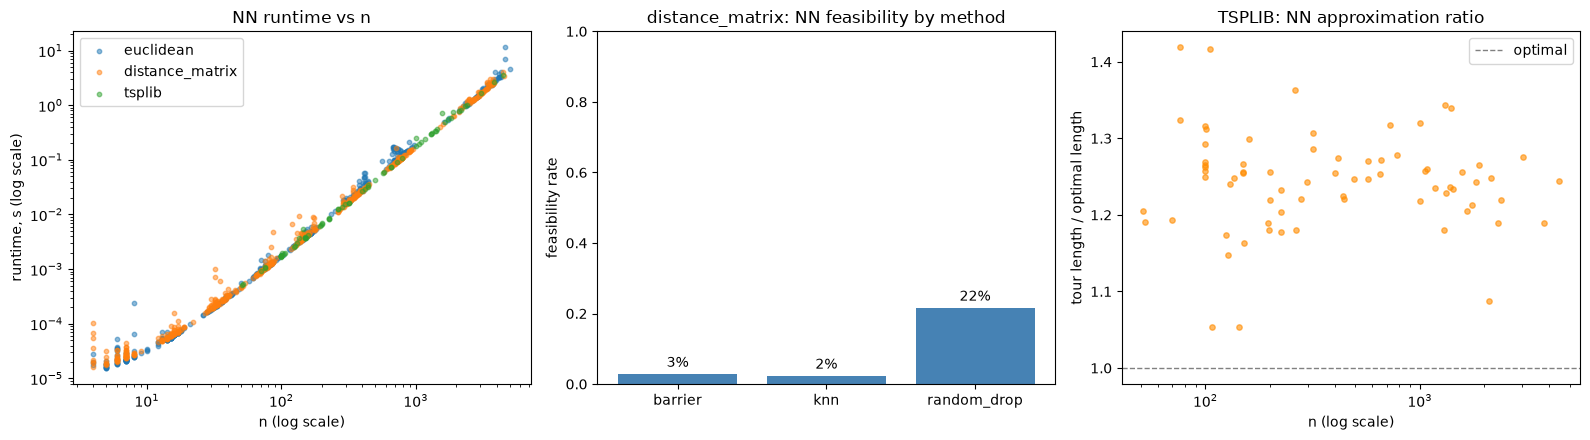

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: runtime vs n, log-log, one series per category
for category in ["euclidean", "distance_matrix", "tsplib"]:
    subset = nn_results[nn_results["category"] == category]
    axes[0].scatter(subset["n"], subset["time"], s=10, alpha=0.5, label=category)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("n (log scale)")
axes[0].set_ylabel("runtime, s (log scale)")
axes[0].set_title("NN runtime vs n")
axes[0].legend()

# Panel 2: feasibility rate by sparsification method (distance_matrix only)
structures = sorted(feasibility_by_structure)
rates = [feasibility_by_structure[s]["feasible"] / feasibility_by_structure[s]["total"] for s in structures]

axes[1].bar(structures, rates, color="steelblue")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("feasibility rate")
axes[1].set_title("distance_matrix: NN feasibility by method")

for i, rate in enumerate(rates):
    axes[1].text(i, rate + 0.02, f"{rate:.0%}", ha="center")

# Panel 3: TSPLIB approximation ratio vs n
tsplib_subset = nn_results[(nn_results["category"] == "tsplib") & nn_results["approx_ratio"].notna()]

axes[2].scatter(tsplib_subset["n"], tsplib_subset["approx_ratio"], s=15, alpha=0.6, color="darkorange")
axes[2].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="optimal")
axes[2].set_xscale("log")
axes[2].set_xlabel("n (log scale)")
axes[2].set_ylabel("tour length / optimal length")
axes[2].set_title("TSPLIB: NN approximation ratio")
axes[2].legend()

plt.tight_layout()
plt.savefig("results/nn_baseline_overview.png", dpi=110)
plt.show()


### Part 2 summary

Actual results from this run:

| | |
|---|---|
| Euclidean instances run | 500, 0 infeasible (complete graph), 145.2s total |
| Distance-matrix instances run | 500, 116.5s total — feasibility: `knn` 2.4% (4/169), `barrier` 2.9% (5/174), `random_drop` 21.7% (34/157) |
| TSPLIB instances run | 72/82 (10 skipped above `TSPLIB_SWEEP_MAX_N`), 18.5s total — approx. ratio vs. published optimum: mean 1.244, min 1.053, max 1.419 |
| Results file | `results/deterministic_nn_results.csv` |

The headline result is the distance-matrix feasibility rate: deterministic
NN fails to complete a genuinely valid tour on **97–98% of `knn` and
`barrier` instances**, and still fails on **78% of `random_drop`**
instances despite that method's sparsity having no relationship to
distance at all. Structured sparsity isn't even required to break NN —
sparsity alone is largely enough; a geographic bottleneck (`barrier`)
makes an already-bad situation only marginally worse than plain `knn`.
That's a strong, concrete answer to the question Part 1 posed this
category to test, and worth carrying into the report as evidence for
*why* randomization (a randomized starting city or randomized candidate
choice) might help NN recover from dead ends that the deterministic,
always-nearest rule walks straight into on any sparse graph.

On the standard Euclidean/TSPLIB formulation, NN behaves as expected from
the literature: roughly 24% above the optimal tour length on average
across real-world TSPLIB benchmarks (mean approximation ratio 1.244),
consistent with NN's known worst-case and typical-case behaviour.

**Part 2 stops here.** Running the three Randomized NN variants
(top-k, distance-weighted, randomized-start) across R=30 seeds per
instance, and the resulting quality/variance analysis, will be Part 3.


## Part 3: Randomized-Start Nearest Neighbor (Version 2A)

The first Randomized NN variant: `algorithms.randomized_start_nearest_neighbor`.
It's exactly the deterministic NN algorithm from Part 2, with one change —
the starting city is drawn uniformly at random instead of always being
city 0. Per the proposal's methodology, each instance is run `R = 30`
times with independent seeds, preserving every run (not just a summary)
so the distribution of outcomes — mean, std, best, worst — can be
characterized rather than collapsed to a single number.

`experiments.run_randomized_over_manifest` (new, alongside Part 2's
`run_nn_over_manifest`) drives this: same manifest-reconstruction and
`load_matrix` pattern as Part 2, but it calls `experiments.run_randomized`
under the hood and keeps all 30 seeded records per instance instead of
one.

**A cost warning before running this cell:** randomized-start NN is the
*same* O(n²) algorithm as deterministic NN — it just starts somewhere
else — so running it R=30 times per instance costs 30x what Part 2 cost.
Extrapolating from Part 2's actual measured runtimes:

| Category | Part 2 (1 run) | This part (R=30) |
|---|---|---|
| Euclidean (500 instances) | 145.2s | ≈ 73 min |
| Distance-matrix (500 instances) | 116.5s | ≈ 58 min |
| TSPLIB (72 instances) | 18.5s | ≈ 9 min |
| **Total** | | **≈ 2.3 hours** |

This code has been smoke-tested (a handful of instances at R=5) but the
full sweep has **not** been executed as part of preparing this notebook —
run the cells below only when you're ready to commit that time (e.g.
overnight, or in the background). The same cost repeats for the
remaining two variants (top-k, distance-weighted) when those are added.


In [ ]:
# R -- number of independent seeds per instance, per the proposal's
# methodology (Section 3.3: "Run Version 2 for R = 30 independent seeds").
RANDOMIZED_RUNS = 30

### Euclidean instances

Reuses the same manifest and `load_euclidean_matrix` closure from Part 2.


In [ ]:
randomized_start_euclidean_records = experiments.run_randomized_over_manifest(
    euclidean_manifest_p2,
    algorithms.randomized_start_nearest_neighbor,
    load_euclidean_matrix,
    algorithm_name="randomized_start",
    runs=RANDOMIZED_RUNS,
    reference_fn=experiments.euclidean_reference,
    label="euclidean/randomized_start",
    progress_every=50,
)

print(f"{len(randomized_start_euclidean_records)} records "
      f"({len(euclidean_manifest_p2)} instances x {RANDOMIZED_RUNS} seeds)")


### Distance-matrix instances

This is the more interesting case: Part 2 found deterministic NN
infeasible on 78-98% of these instances (depending on sparsification
method). Randomizing the start city gives NN a different entry point
into the graph on each of the 30 seeds — worth checking whether that
alone raises the feasibility rate, or whether the graph structure itself
makes almost every starting point equally likely to dead-end.


In [ ]:
randomized_start_dm_records = experiments.run_randomized_over_manifest(
    distance_matrix_manifest_p2,
    algorithms.randomized_start_nearest_neighbor,
    load_sparse_dense_matrix,
    algorithm_name="randomized_start",
    runs=RANDOMIZED_RUNS,
    label="distance_matrix/randomized_start",
    progress_every=50,
)

print(f"{len(randomized_start_dm_records)} records "
      f"({len(distance_matrix_manifest_p2)} instances x {RANDOMIZED_RUNS} seeds)")


### TSPLIB benchmark instances

Same 72-instance size-capped set as Part 2, so the approximation-ratio
comparison below is apples-to-apples with the deterministic baseline.


In [ ]:
randomized_start_tsplib_records = experiments.run_randomized_over_manifest(
    tsplib_manifest_p2,
    algorithms.randomized_start_nearest_neighbor,
    load_tsplib_matrix,
    algorithm_name="randomized_start",
    runs=RANDOMIZED_RUNS,
    reference_fn=experiments.tsplib_reference,
    label="tsplib/randomized_start",
    progress_every=20,
)

print(f"{len(randomized_start_tsplib_records)} records "
      f"({len(tsplib_manifest_p2)} instances x {RANDOMIZED_RUNS} seeds)")


### Combined results

Appends this variant's records into `results/deterministic_nn_results.csv`
alongside Part 2's deterministic runs, rather than a separate file — so
later parts (top-k, weighted) can all accumulate into one CSV that the
final analysis part reads once. Re-running this cell replaces this
variant's own rows rather than duplicating them, so it's safe to re-run.


In [ ]:
RESULTS_PATH = "results/deterministic_nn_results.csv"

randomized_start_df = pd.DataFrame(
    randomized_start_euclidean_records
    + randomized_start_dm_records
    + randomized_start_tsplib_records
)

existing_results = pd.read_csv(RESULTS_PATH) if os.path.exists(RESULTS_PATH) else pd.DataFrame()

if not existing_results.empty:
    # Drop any previous run of this same variant before appending, so
    # re-running this cell replaces its contribution instead of piling
    # up duplicate rows.
    existing_results = existing_results[existing_results["algorithm"] != "randomized_start"]

all_results = pd.concat([existing_results, randomized_start_df], ignore_index=True)
all_results.to_csv(RESULTS_PATH, index=False)

print(f"appended {len(randomized_start_df)} randomized_start records; "
      f"{RESULTS_PATH} now has {len(all_results)} total records "
      f"across algorithms: {sorted(all_results['algorithm'].unique())}")


### Does randomizing the start city rescue feasibility?

Two different questions, both worth asking:

1. **Per-run feasibility rate** — of all 30 seeded attempts, what
   fraction individually succeed? (Directly comparable to Part 2's
   single deterministic run.)
2. **At-least-one-of-30 feasibility rate** — per instance, does *at
   least one* of the 30 random starts find a feasible tour? This is the
   proposal's "randomized start, repeated over multiple trials, keeping
   the best" idea in its most basic form: even a low per-run success
   rate can still be useful if trying several starts is cheap and only
   one needs to work.


In [ ]:
dm_results = all_results[all_results["category"] == "distance_matrix"]
det = dm_results[dm_results["algorithm"] == "deterministic_nn"]
rand = dm_results[dm_results["algorithm"] == "randomized_start"]

det_per_run = det.groupby("structure")["feasible"].mean()
rand_per_run = rand.groupby("structure")["feasible"].mean()
rand_any_of_r = rand.groupby(["structure", "instance"])["feasible"].any().groupby("structure").mean()

print(f"{'method':<14}{'deterministic':>15}{'random-start (per-run)':>25}{'random-start (any of ' + str(RANDOMIZED_RUNS) + ')':>28}")
for structure in sorted(det_per_run.index):
    print(
        f"{structure:<14}"
        f"{det_per_run[structure]:>15.1%}"
        f"{rand_per_run[structure]:>25.1%}"
        f"{rand_any_of_r[structure]:>28.1%}"
    )


### Does randomizing the start city improve solution quality?

On TSPLIB, where every run has a real approximation ratio against the
published optimum: compare deterministic NN's single ratio against the
**best of the 30** randomized-start ratios per instance — the proposal's
"repeated over multiple trials, keeping the best tour found" strategy in
practice.


In [ ]:
tsplib_results = all_results[all_results["category"] == "tsplib"]

det_ratio = tsplib_results[tsplib_results["algorithm"] == "deterministic_nn"].set_index("instance")["approx_ratio"]
rand_best_ratio = tsplib_results[tsplib_results["algorithm"] == "randomized_start"].groupby("instance")["approx_ratio"].min()

quality_comparison = pd.concat(
    [det_ratio.rename("deterministic"), rand_best_ratio.rename(f"randomized_start_best_of_{RANDOMIZED_RUNS}")],
    axis=1,
).dropna()

improved = (quality_comparison.iloc[:, 1] < quality_comparison.iloc[:, 0]).sum()

print(f"deterministic NN:                 mean approx ratio = {quality_comparison.iloc[:, 0].mean():.3f}")
print(f"randomized-start (best of {RANDOMIZED_RUNS}):     mean approx ratio = {quality_comparison.iloc[:, 1].mean():.3f}")
print(f"instances where the best-of-{RANDOMIZED_RUNS} start beat deterministic: {improved}/{len(quality_comparison)}")


### Variance across seeds

The mean/best numbers above hide how spread out the 30 outcomes are per
instance. A boxplot of tour length across seeds, with the deterministic
NN length as a reference line, makes that spread visible directly.
Four TSPLIB instances are sampled evenly across the size range actually
run (rather than hardcoding specific names), so this cell keeps working
if `TSPLIB_SWEEP_MAX_N` or the bundled instance set changes later.


In [ ]:
tsplib_instances_by_size = (
    all_results[all_results["category"] == "tsplib"][["instance", "n"]]
    .drop_duplicates()
    .sort_values("n")
    .reset_index(drop=True)
)

n_examples = min(4, len(tsplib_instances_by_size))
step = max(1, (len(tsplib_instances_by_size) - 1) // (n_examples - 1)) if n_examples > 1 else 1
sample_positions = sorted(set(min(i * step, len(tsplib_instances_by_size) - 1) for i in range(n_examples)))
example_instances = tsplib_instances_by_size.iloc[sample_positions]["instance"].tolist()

fig, axes = plt.subplots(1, len(example_instances), figsize=(4 * len(example_instances), 4.5))
if len(example_instances) == 1:
    axes = [axes]

for ax, instance in zip(axes, example_instances):
    lengths = all_results[(all_results["instance"] == instance) & (all_results["algorithm"] == "randomized_start")]["length"]
    det_length = all_results[(all_results["instance"] == instance) & (all_results["algorithm"] == "deterministic_nn")]["length"].iloc[0]

    ax.boxplot(lengths, tick_labels=["randomized_start"])
    ax.axhline(det_length, color="red", linestyle="--", label="deterministic NN")
    ax.set_title(instance)
    ax.set_ylabel("tour length")
    ax.legend()

plt.tight_layout()
plt.savefig("results/randomized_start_variance.png", dpi=110)
plt.show()


### Part 3 summary

**This part has not been executed yet** — as agreed, only the code was
written; the full R=30 sweep (~2.3 hours, see the warning above) is left
for you to run when ready. Once it has been run, replace this paragraph
with the actual numbers, mirroring Part 2's summary: total records,
the feasibility-rate table (deterministic vs. per-run vs. any-of-30), and
the TSPLIB quality comparison (mean approximation ratio, instances
improved).

**Part 3 stops here.** The remaining two Randomized NN variants —
top-k (`randomized_nearest_neighbor_top_k`, Version 2B) and
distance-weighted (`randomized_nearest_neighbor_weighted`, Version 2C) —
will be Part 4 and Part 5, each following the same pattern established
here. After all three variants are in `results/deterministic_nn_results.csv`,
a final analysis part can compare all four algorithms together.


## Part 4: Top-k Randomized Nearest Neighbor (Version 2B)

The second Randomized NN variant: `algorithms.randomized_nearest_neighbor_top_k`.
At each step, instead of always moving to the single nearest unvisited
city, it picks uniformly at random among the `k` nearest unvisited
candidates (`k=1` recovers plain deterministic NN — already covered by
Part 2, so it's excluded here to avoid spending R=30 runs reproducing a
zero-variance result). The starting city is kept fixed (`random_start=False`),
matching `experiments.RANDOMIZED_VARIANTS`'s existing convention, so any
effect measured here is isolated to the candidate-choice randomization
itself, not conflated with a randomized start (that's what Part 3 already
tested).

Unlike Part 3, this variant has a free parameter worth sweeping rather
than fixing: how many candidates should "nearby" include before the
choice degrades from "mostly greedy with a little noise" to "close to
uniform random"? `TOP_K_VALUES` below is tested against every instance,
each still with `R = 30` seeds, using the same `run_randomized_over_manifest`
helper from Part 3 — one call per `k`, tagging each with its own algorithm
name (`top_k_k2`, `top_k_k3`, ...) so they stay distinguishable in the
combined results file.

**Cost warning:** each `k` costs the same as Part 3's full run (~2.3
hours), since top-k NN is still O(n²) per run — the only difference from
randomized-start is which candidate gets picked. Testing
`len(TOP_K_VALUES)` values multiplies that:

| `TOP_K_VALUES` | Estimated total runtime |
|---|---|
| `[2, 3, 5, 10]` (as configured below) | ≈ 4 × 2.3h ≈ **9.2 hours** |

As with Part 3, **this code has been smoke-tested on small samples but
the full sweep has not been executed** — run it only when you're ready
to commit that time, and consider trimming `TOP_K_VALUES` first if 9+
hours isn't practical before the report is due.


In [ ]:
# Candidate-pool sizes to test. k=1 (plain NN) is intentionally excluded
# -- see markdown above. Spans "barely randomized" (2) to "considering a
# fairly wide neighbourhood" (10).
TOP_K_VALUES = [2, 3, 5, 10]

### Euclidean instances

Same manifest and `load_euclidean_matrix` closure as Parts 2-3, one
`run_randomized_over_manifest` call per `k`.


In [ ]:
top_k_euclidean_records = []

for k in TOP_K_VALUES:
    records = experiments.run_randomized_over_manifest(
        euclidean_manifest_p2,
        algorithms.randomized_nearest_neighbor_top_k,
        load_euclidean_matrix,
        algorithm_name=f"top_k_k{k}",
        runs=RANDOMIZED_RUNS,
        reference_fn=experiments.euclidean_reference,
        label=f"euclidean/top_k_k{k}",
        progress_every=100,
        k=k,
        random_start=False,
    )
    top_k_euclidean_records += records
    print(f"k={k}: {len(records)} records")

print(f"euclidean top-k total: {len(top_k_euclidean_records)} records "
      f"({len(euclidean_manifest_p2)} instances x {RANDOMIZED_RUNS} seeds x {len(TOP_K_VALUES)} k values)")


### Distance-matrix instances

Worth watching here: does a **larger** `k` make feasibility better or
worse? A larger candidate pool gives NN more chances to pick a city that
still has a way out later, but it also means more of those candidates
might be unreachable-in-practice dead ends the deterministic nearest-only
rule would have avoided by luck. Not obvious which direction wins ahead
of time.


In [ ]:
top_k_dm_records = []

for k in TOP_K_VALUES:
    records = experiments.run_randomized_over_manifest(
        distance_matrix_manifest_p2,
        algorithms.randomized_nearest_neighbor_top_k,
        load_sparse_dense_matrix,
        algorithm_name=f"top_k_k{k}",
        runs=RANDOMIZED_RUNS,
        label=f"distance_matrix/top_k_k{k}",
        progress_every=100,
        k=k,
        random_start=False,
    )
    top_k_dm_records += records
    print(f"k={k}: {len(records)} records")

print(f"distance_matrix top-k total: {len(top_k_dm_records)} records "
      f"({len(distance_matrix_manifest_p2)} instances x {RANDOMIZED_RUNS} seeds x {len(TOP_K_VALUES)} k values)")


### TSPLIB benchmark instances

Same 72-instance size-capped set as Parts 2-3.


In [ ]:
top_k_tsplib_records = []

for k in TOP_K_VALUES:
    records = experiments.run_randomized_over_manifest(
        tsplib_manifest_p2,
        algorithms.randomized_nearest_neighbor_top_k,
        load_tsplib_matrix,
        algorithm_name=f"top_k_k{k}",
        runs=RANDOMIZED_RUNS,
        reference_fn=experiments.tsplib_reference,
        label=f"tsplib/top_k_k{k}",
        progress_every=20,
        k=k,
        random_start=False,
    )
    top_k_tsplib_records += records
    print(f"k={k}: {len(records)} records")

print(f"tsplib top-k total: {len(top_k_tsplib_records)} records "
      f"({len(tsplib_manifest_p2)} instances x {RANDOMIZED_RUNS} seeds x {len(TOP_K_VALUES)} k values)")


### Combined results

Appends into the same `results/deterministic_nn_results.csv` as Parts 2-3.
Re-running this cell replaces every `top_k_k*` row rather than duplicating
them (matching every `k` currently in `TOP_K_VALUES`, not just one), so
changing `TOP_K_VALUES` and re-running is safe.


In [ ]:
top_k_df = pd.DataFrame(top_k_euclidean_records + top_k_dm_records + top_k_tsplib_records)

existing_results = pd.read_csv(RESULTS_PATH) if os.path.exists(RESULTS_PATH) else pd.DataFrame()

if not existing_results.empty:
    # Drop every previous top-k row (any k), not just the ones in the
    # current TOP_K_VALUES -- so shrinking/changing that list and
    # re-running doesn't leave stale k's behind.
    existing_results = existing_results[~existing_results["algorithm"].str.startswith("top_k_")]

all_results = pd.concat([existing_results, top_k_df], ignore_index=True)
all_results.to_csv(RESULTS_PATH, index=False)

print(f"appended {len(top_k_df)} top-k records across k={TOP_K_VALUES}; "
      f"{RESULTS_PATH} now has {len(all_results)} total records "
      f"across algorithms: {sorted(all_results['algorithm'].unique())}")


### How does k affect solution quality?

On TSPLIB: mean and standard deviation of the approximation ratio at
each `k`, against the deterministic NN baseline from Part 2. `k` is
parsed back out of the `top_k_k{k}` algorithm name rather than kept as a
separate column, since the combined results file only has `algorithm`
(this keeps the CSV schema identical to Parts 2-3's, so a generic loader
doesn't need special-casing for this variant).


In [ ]:
tsplib_results = all_results[all_results["category"] == "tsplib"].copy()

top_k_tsplib = tsplib_results[tsplib_results["algorithm"].str.startswith("top_k_")].copy()
top_k_tsplib["k"] = top_k_tsplib["algorithm"].str.removeprefix("top_k_k").astype(int)

quality_by_k = top_k_tsplib.groupby("k")["approx_ratio"].agg(["mean", "std", "min", "max"]).sort_index()

det_mean_ratio = tsplib_results[tsplib_results["algorithm"] == "deterministic_nn"]["approx_ratio"].mean()

print(f"deterministic NN mean approx ratio: {det_mean_ratio:.3f}\n")
print("top-k mean approx ratio by k:")
print(quality_by_k)


### How does k affect distance-matrix feasibility?

Same per-run / any-of-R framing as Part 3, but now compared across `k`
and sparsification method.


In [ ]:
dm_results = all_results[all_results["category"] == "distance_matrix"].copy()

top_k_dm = dm_results[dm_results["algorithm"].str.startswith("top_k_")].copy()
top_k_dm["k"] = top_k_dm["algorithm"].str.removeprefix("top_k_k").astype(int)

det_dm_feasibility = dm_results[dm_results["algorithm"] == "deterministic_nn"].groupby("structure")["feasible"].mean()
top_k_per_run = top_k_dm.groupby(["structure", "k"])["feasible"].mean()
top_k_any_of_r = (
    top_k_dm.groupby(["structure", "k", "instance"])["feasible"].any()
    .groupby(["structure", "k"]).mean()
)

for structure in sorted(det_dm_feasibility.index):
    print(f"{structure} (deterministic: {det_dm_feasibility[structure]:.1%})")
    print(f"  {'k':>4}{'per-run':>12}{'any-of-' + str(RANDOMIZED_RUNS):>14}")
    for k in TOP_K_VALUES:
        print(f"  {k:>4}{top_k_per_run.get((structure, k), float('nan')):>12.1%}{top_k_any_of_r.get((structure, k), float('nan')):>14.1%}")
    print()


### Part 4 visual summary

Two views: how mean TSPLIB approximation ratio (± std across seeds and
instances) moves as `k` grows, against the deterministic baseline; and
how distance-matrix feasibility rate moves with `k`, one line per
sparsification method.


In [ ]:
feasibility_by_k = top_k_dm.groupby(["structure", "k"])["feasible"].mean().unstack("structure")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].errorbar(
    quality_by_k.index, quality_by_k["mean"], yerr=quality_by_k["std"],
    marker="o", capsize=3, label="top-k",
)
axes[0].axhline(det_mean_ratio, color="gray", linestyle="--", label="deterministic NN")
axes[0].set_xlabel("k")
axes[0].set_ylabel("mean approx ratio")
axes[0].set_title("TSPLIB: quality vs k")
axes[0].legend()

for structure in feasibility_by_k.columns:
    axes[1].plot(feasibility_by_k.index, feasibility_by_k[structure], marker="o", label=structure)

axes[1].set_xlabel("k")
axes[1].set_ylabel("feasibility rate (per-run)")
axes[1].set_ylim(0, 1)
axes[1].set_title("distance_matrix: feasibility vs k")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/top_k_overview.png", dpi=110)
plt.show()


### Part 4 summary

**This part has not been executed yet** — only the code was written, per
the same agreement as Part 3. The full sweep (`TOP_K_VALUES = [2, 3, 5, 10]`,
R=30 each) is estimated at ~9.2 hours; trim `TOP_K_VALUES` before running
if that's not practical. Once it has been run, replace this paragraph
with the actual numbers: the quality-vs-k and feasibility-vs-k tables,
and whether the direction of each trend matched the intuition in the
markdown above (does more randomization hurt quality monotonically? does
it help or hurt distance-matrix feasibility?).

**Part 4 stops here.** The remaining Randomized NN variant —
distance-weighted (`randomized_nearest_neighbor_weighted`, Version 2C) —
will be Part 5, followed by a final analysis part comparing all four
algorithms (deterministic NN, randomized-start, top-k across every `k`,
and weighted) together.
